# SHAP Forecast Explanation

This notebook explains the surplus forecast.

## Purpose

Explain the renewable-surplus forecast with SHAP.

If saved model files are missing, the notebook trains a labelled fallback model so the explanation workflow can still be checked.

SHAP shows how the model used its inputs. It does not prove cause and effect.

In [1]:
from pathlib import Path
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the root or Notebooks directory."""
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing Data/ and Notebooks/.")


ROOT = find_project_root()
DATA_DIR = ROOT / "Data"
RESULTS_DIR = DATA_DIR / "Results"
PROCESSED_DIR = DATA_DIR / "Processed"
FIGURES_DIR = ROOT / "Figures"
MODELS_DIR = ROOT / "Models" / "Forecasting"

for directory in [RESULTS_DIR, PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INTERVAL_MINUTES = 5
INTERVAL_HOURS = INTERVAL_MINUTES / 60
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"Project root: {ROOT}")

Project root: /Users/mac/Send-Ev-Project/SEND-EV-Project


In [2]:
def save_table(df: pd.DataFrame, path: Path) -> Path:
    """Save Parquet where available, otherwise save CSV with the same stem."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix.lower() == ".parquet":
        try:
            df.to_parquet(path, index=False)
            print(f"Saved: {path.relative_to(ROOT)}")
            return path
        except (ImportError, ModuleNotFoundError) as exc:
            csv_path = path.with_suffix(".csv")
            df.to_csv(csv_path, index=False)
            print(f"Parquet engine unavailable ({exc.__class__.__name__}); saved CSV: {csv_path.relative_to(ROOT)}")
            return csv_path
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def read_table(path: Path, parse_dates: list[str] | None = None) -> pd.DataFrame:
    """Read a Parquet/CSV output regardless of which format was written."""
    candidates = [path]
    if path.suffix.lower() == ".parquet":
        candidates.append(path.with_suffix(".csv"))
    elif path.suffix.lower() == ".csv":
        candidates.append(path.with_suffix(".parquet"))

    parquet_error: Exception | None = None

    for candidate in candidates:
        if candidate.exists():
            if candidate.suffix.lower() == ".parquet":
                try:
                    return pd.read_parquet(candidate)
                except (ImportError, ModuleNotFoundError) as exc:
                    parquet_error = exc
                    continue
            return pd.read_csv(candidate, parse_dates=parse_dates)

    if parquet_error is not None:
        raise ImportError(
            "A Parquet file exists, but pandas cannot read it and no CSV fallback was found. "
            "Install pyarrow or fastparquet, or rerun the previous notebook to create the CSV fallback."
        ) from parquet_error

    raise FileNotFoundError(f"None of these files exists: {candidates}")

In [3]:
import joblib
try:
    import shap
except ImportError as exc:
    shap = None
    SHAP_IMPORT_ERROR = exc
else:
    SHAP_IMPORT_ERROR = None
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb

send = read_table(PROCESSED_DIR / "send_solcast_surplus_5min.parquet", parse_dates=["DateTime"])
send["DateTime"] = pd.to_datetime(send["DateTime"], errors="coerce")
send = send.sort_values("DateTime").reset_index(drop=True)

## 1. Prepare leakage-safe features

In [4]:
def build_surplus_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    df = frame.copy().sort_values("DateTime")
    dt = df["DateTime"]

    features = pd.DataFrame(index=df.index)
    for column in [
        "air_temp", "gti", "surface_pressure", "snow_depth", "cloud_opacity",
        "ghi", "clearsky_gti", "wind_speed_100m",
    ]:
        if column in df.columns:
            features[column] = pd.to_numeric(df[column], errors="coerce")

    features["hour_sin"] = np.sin(2 * np.pi * (dt.dt.hour * 60 + dt.dt.minute) / (24 * 60))
    features["hour_cos"] = np.cos(2 * np.pi * (dt.dt.hour * 60 + dt.dt.minute) / (24 * 60))
    features["dayofyear_sin"] = np.sin(2 * np.pi * dt.dt.dayofyear / 365.25)
    features["dayofyear_cos"] = np.cos(2 * np.pi * dt.dt.dayofyear / 365.25)
    features["day_of_week"] = dt.dt.dayofweek
    features["is_weekend"] = dt.dt.dayofweek.ge(5).astype(int)

    for target_column in ["solar_kw", "wind_kw", "consumption_kw", "surplus_kw"]:
        if target_column not in df.columns:
            continue
        series = pd.to_numeric(df[target_column], errors="coerce")
        for lag in [1, 12, 288, 2016]:
            features[f"{target_column}_lag_{lag}"] = series.shift(lag)
        features[f"{target_column}_rolling_1h"] = series.shift(1).rolling(12).mean()
        features[f"{target_column}_rolling_3h"] = series.shift(1).rolling(36).mean()
        features[f"{target_column}_rolling_1d"] = series.shift(1).rolling(288).mean()

    target = pd.to_numeric(df["surplus_kw"], errors="coerce")
    valid = features.notna().all(axis=1) & target.notna()
    return features.loc[valid], target.loc[valid], dt.loc[valid]


X, y, timestamps = build_surplus_features(send)
print(X.shape, y.shape)
display(X.head())

(179183, 42) (179183,)


,air_temp,gti,surface_pressure,snow_depth,cloud_opacity,ghi,clearsky_gti,wind_speed_100m,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,day_of_week,is_weekend,solar_kw_lag_1,solar_kw_lag_12,solar_kw_lag_288,solar_kw_lag_2016,solar_kw_rolling_1h,solar_kw_rolling_3h,solar_kw_rolling_1d,wind_kw_lag_1,wind_kw_lag_12,wind_kw_lag_288,wind_kw_lag_2016,wind_kw_rolling_1h,wind_kw_rolling_3h,wind_kw_rolling_1d,consumption_kw_lag_1,consumption_kw_lag_12,consumption_kw_lag_288,consumption_kw_lag_2016,consumption_kw_rolling_1h,consumption_kw_rolling_3h,consumption_kw_rolling_1d,surplus_kw_lag_1,surplus_kw_lag_12,surplus_kw_lag_288,surplus_kw_lag_2016,surplus_kw_rolling_1h,surplus_kw_rolling_3h,surplus_kw_rolling_1d
14064,9,0,997.2,0.0,48.5,0,0,2.8,-0.866025,0.500000,0.959079,-0.283139,0,0,0.0,9.885,0.0,0.0,0.906833,57.798056,581.580861,0.0,0.0,124.508,647.012,0.0,10.084111,49.775990,1102.953,1030.835,1036.939,1442.948,1089.495833,1118.654833,1207.975549,0.0,0.0,0.0,0.0,0.0,0.0,75.966368
14065,9,0,997.2,0.0,46.6,0,0,2.8,-0.854912,0.518773,0.959079,-0.283139,0,0,0.0,0.997,0.0,0.0,0.083083,54.018639,581.580861,0.0,0.0,137.918,446.360,0.0,5.668167,49.343670,1111.540,1047.350,1031.047,1451.894,1096.221250,1116.723694,1208.234580,0.0,0.0,0.0,0.0,0.0,0.0,75.966368
14066,9,0,997.2,0.0,45.5,0,0,2.8,-0.843391,0.537300,0.959079,-0.283139,0,0,0.0,0.000,0.0,0.0,0.000000,50.900611,581.580861,0.0,0.0,91.099,559.677,0.0,1.697417,48.864788,1120.218,1049.417,1043.441,1458.687,1102.293583,1114.829583,1208.544201,0.0,0.0,0.0,0.0,0.0,0.0,75.966368
14067,9,0,997.2,0.0,44.5,0,0,2.8,-0.831470,0.555570,0.959079,-0.283139,0,0,0.0,0.000,0.0,0.0,0.000000,48.444389,581.580861,0.0,0.0,45.318,553.232,0.0,0.983250,48.548472,1077.721,1093.366,1053.312,1451.800,1104.652250,1112.537083,1208.663229,0.0,0.0,0.0,0.0,0.0,0.0,75.966368
14068,9,0,997.2,0.0,43.5,0,0,2.9,-0.819152,0.573576,0.959079,-0.283139,0,0,0.0,0.000,0.0,0.0,0.000000,45.970111,581.580861,0.0,0.0,20.641,423.277,0.0,0.323389,48.391118,1067.394,1113.197,1024.473,1415.177,1102.487917,1109.669806,1208.712125,0.0,0.0,0.0,0.0,0.0,0.0,75.966368


## 2. Load the final model or train the labelled fallback

In [5]:
MODEL_PATH = MODELS_DIR / "xgb_surplus.joblib"
FEATURES_PATH = RESULTS_DIR / "surplus_test_features.csv"
TRAIN_FALLBACK_IF_MISSING = True

split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
time_test = timestamps.iloc[split:]

if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
    model_origin = "saved_final_model"
else:
    if not TRAIN_FALLBACK_IF_MISSING:
        raise FileNotFoundError(MODEL_PATH)
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    joblib.dump(model, MODEL_PATH)
    model_origin = "fallback_model_trained_in_notebook"
    print("WARNING: A fallback model was trained. Replace it with the final chronologically validated model before reporting dissertation results.")

predictions = np.maximum(model.predict(X_test), 0)
print({
    "model_origin": model_origin,
    "MAE": mean_absolute_error(y_test, predictions),
    "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
    "R2": r2_score(y_test, predictions),
})

prediction_output = X_test.copy()
prediction_output.insert(0, "DateTime", time_test.to_numpy())
prediction_output["surplus_actual_kw"] = y_test.to_numpy()
prediction_output["surplus_pred_xgb"] = predictions
save_table(prediction_output, RESULTS_DIR / "surplus_test_features.csv")
save_table(
    prediction_output[["DateTime", "surplus_actual_kw", "surplus_pred_xgb"]],
    RESULTS_DIR / "surplus_predictions.csv",
)

{'model_origin': 'fallback_model_trained_in_notebook', 'MAE': 24.242718012774244, 'RMSE': 106.58023803318709, 'R2': 0.726095664178384}
Saved: Data/Results/surplus_test_features.csv
Saved: Data/Results/surplus_predictions.csv


PosixPath('/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/surplus_predictions.csv')

## 3. Calculate TreeSHAP values

In [6]:
MAX_EXPLANATION_ROWS = 2_000
if len(X_test) > MAX_EXPLANATION_ROWS:
    sample_index = np.linspace(0, len(X_test) - 1, MAX_EXPLANATION_ROWS, dtype=int)
    X_explain = X_test.iloc[sample_index]
    y_explain = y_test.iloc[sample_index]
    t_explain = time_test.iloc[sample_index]
    p_explain = predictions[sample_index]
else:
    X_explain, y_explain, t_explain, p_explain = X_test, y_test, time_test, predictions

if shap is not None:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_explain)
    contribution_values = shap_values.values
    contribution_base_values = np.asarray(shap_values.base_values)
    explanation_backend = "shap.TreeExplainer"
else:
    print("SHAP import failed; using XGBoost pred_contribs fallback:", SHAP_IMPORT_ERROR)
    matrix = xgb.DMatrix(X_explain, feature_names=list(X_explain.columns))
    contributions = model.get_booster().predict(matrix, pred_contribs=True)
    contribution_values = contributions[:, :-1]
    contribution_base_values = contributions[:, -1]
    shap_values = None
    explanation_backend = "xgboost.pred_contribs"

importance = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": np.abs(contribution_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
importance["explanation_backend"] = explanation_backend
save_table(importance, RESULTS_DIR / "shap_feature_importance.csv")
display(importance.head(20))


SHAP import failed; using XGBoost pred_contribs fallback: Numba needs NumPy 2.3 or less. Got NumPy 2.5.
Saved: Data/Results/shap_feature_importance.csv


,feature,mean_abs_shap,explanation_backend
35,surplus_kw_lag_1,52.630470,xgboost.pred_contribs
5,ghi,25.797388,xgboost.pred_contribs
39,surplus_kw_rolling_1h,17.766844,xgboost.pred_contribs
1,gti,13.017231,xgboost.pred_contribs
14,solar_kw_lag_1,8.989111,xgboost.pred_contribs
18,solar_kw_rolling_1h,7.214214,xgboost.pred_contribs
4,cloud_opacity,2.940289,xgboost.pred_contribs
40,surplus_kw_rolling_3h,2.760853,xgboost.pred_contribs
32,consumption_kw_rolling_1h,2.598287,xgboost.pred_contribs
28,consumption_kw_lag_1,2.538058,xgboost.pred_contribs


## 4. Global explanation plots

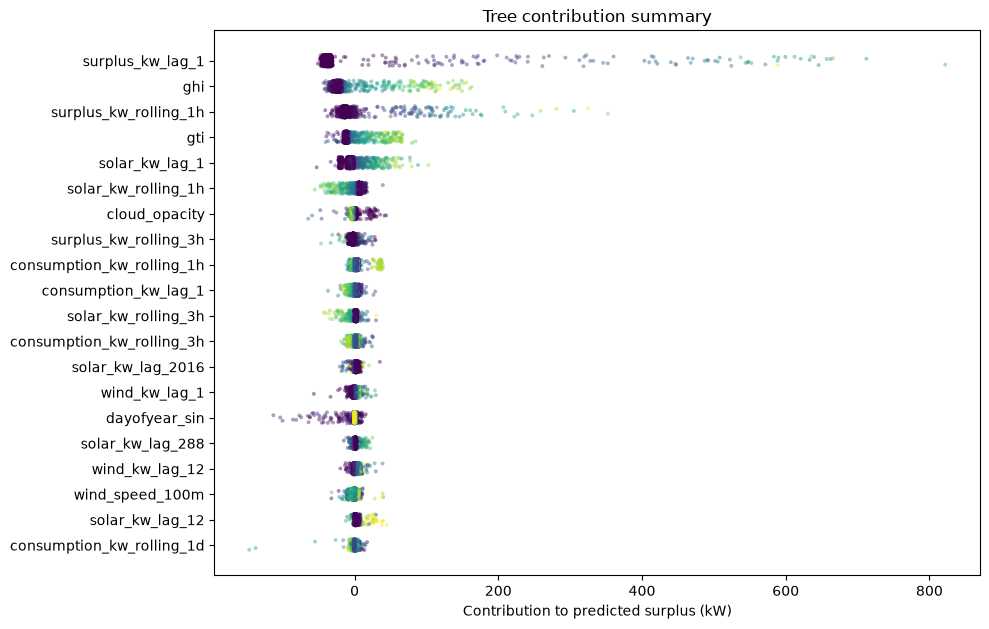

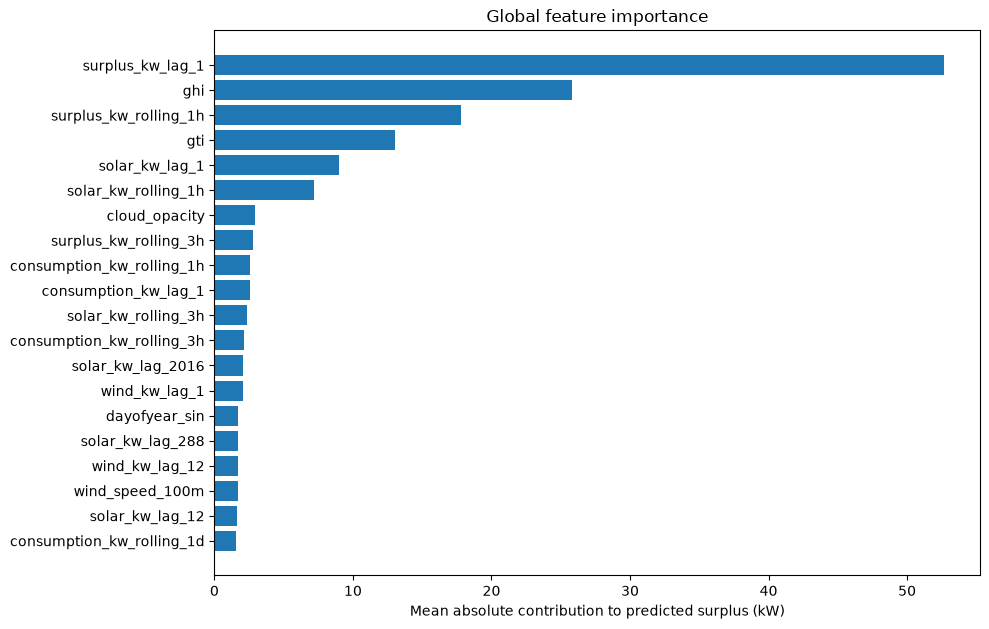

In [7]:
if shap is not None:
    plt.figure()
    shap.summary_plot(contribution_values, X_explain, show=False, max_display=20)
else:
    top_features = importance.head(20)["feature"].tolist()
    plot_features = list(reversed(top_features))
    plt.figure(figsize=(10, max(6, len(plot_features) * 0.32)))
    for position, feature in enumerate(plot_features):
        column_index = X_explain.columns.get_loc(feature)
        values = contribution_values[:, column_index]
        feature_values = pd.to_numeric(X_explain[feature], errors="coerce").to_numpy(dtype=float)
        jitter = rng.uniform(-0.22, 0.22, size=len(values))
        plt.scatter(values, position + jitter, c=feature_values, cmap="viridis", s=8, alpha=0.45, edgecolors="none")
    plt.yticks(range(len(plot_features)), plot_features)
    plt.xlabel("Contribution to predicted surplus (kW)")
    plt.title("Tree contribution summary")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

if shap is not None:
    plt.figure()
    shap.summary_plot(contribution_values, X_explain, plot_type="bar", show=False, max_display=20)
else:
    top = importance.head(20).sort_values("mean_abs_shap")
    plt.figure(figsize=(10, max(6, len(top) * 0.32)))
    plt.barh(top["feature"], top["mean_abs_shap"])
    plt.xlabel("Mean absolute contribution to predicted surplus (kW)")
    plt.title("Global feature importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_global_bar.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Explain representative events

high_surplus {'DateTime': Timestamp('2023-10-04 11:30:00'), 'actual': 3361.7943329883174, 'predicted': 999.9169311523438, 'error': -2361.8774018359736, 'actual_event': True, 'predicted_event': True}


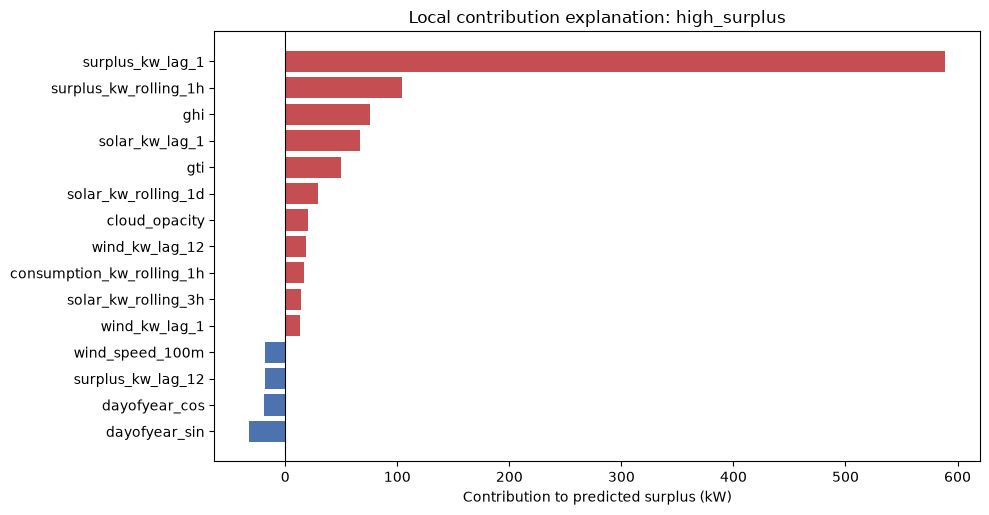

largest_overprediction {'DateTime': Timestamp('2023-08-30 14:55:00'), 'actual': 0.0, 'predicted': 838.0361328125, 'error': 838.0361328125, 'actual_event': False, 'predicted_event': True}


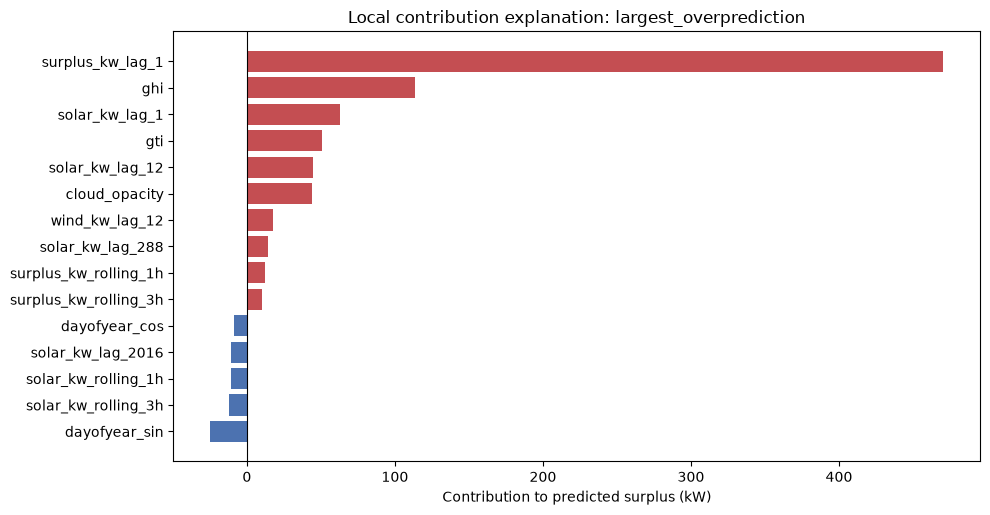

largest_underprediction {'DateTime': Timestamp('2023-10-04 11:30:00'), 'actual': 3361.7943329883174, 'predicted': 999.9169311523438, 'error': -2361.8774018359736, 'actual_event': True, 'predicted_event': True}


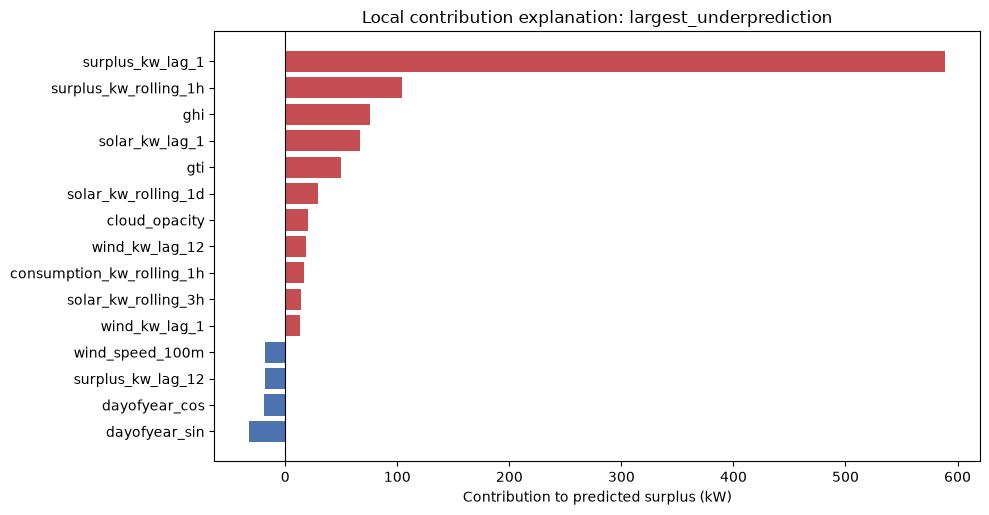

In [8]:
event_table = pd.DataFrame({
    "DateTime": t_explain.to_numpy(),
    "actual": y_explain.to_numpy(),
    "predicted": p_explain,
})
event_table["error"] = event_table["predicted"] - event_table["actual"]
event_table["actual_event"] = event_table["actual"] > 1.0
event_table["predicted_event"] = event_table["predicted"] > 1.0

candidate_indices = {
    "high_surplus": int(np.argmax(event_table["actual"].to_numpy())),
    "largest_overprediction": int(np.argmax(event_table["error"].to_numpy())),
    "largest_underprediction": int(np.argmin(event_table["error"].to_numpy())),
}

for label, position in candidate_indices.items():
    print(label, event_table.iloc[position].to_dict())
    if shap is not None:
        shap.plots.waterfall(shap_values[position], max_display=15, show=False)
    else:
        local = pd.Series(contribution_values[position], index=X_explain.columns)
        local = local.reindex(local.abs().sort_values(ascending=False).head(15).index).sort_values()
        colours = np.where(local.to_numpy() >= 0, "#c44e52", "#4c72b0")
        plt.figure(figsize=(10, max(5, len(local) * 0.35)))
        plt.barh(local.index, local.to_numpy(), color=colours)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.xlabel("Contribution to predicted surplus (kW)")
        plt.title(f"Local contribution explanation: {label}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_waterfall_{label}.png", dpi=200, bbox_inches="tight")
    plt.show()


## Reporting caution

Treat SHAP values as model explanations, not proof that one variable physically caused another.